In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup

In [27]:
df = pd.read_csv('/Users/benkan45d6/GitHub/Intro-To-DataScience/working/data/google_serp_top30_from_json.csv')

/var/folders/0w/q_1_pqq95mn4k4mk87c1p7rc0000gn/T/ipykernel_24355/3289669460.py:45: UserWarning: Glyph 22781 (\N{CJK UNIFIED IDEOGRAPH-58FD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0w/q_1_pqq95mn4k4mk87c1p7rc0000gn/T/ipykernel_24355/3289669460.py:45: UserWarning: Glyph 21916 (\N{CJK UNIFIED IDEOGRAPH-559C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0w/q_1_pqq95mn4k4mk87c1p7rc0000gn/T/ipykernel_24355/3289669460.py:45: UserWarning: Glyph 12539 (\N{KATAKANA MIDDLE DOT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0w/q_1_pqq95mn4k4mk87c1p7rc0000gn/T/ipykernel_24355/3289669460.py:45: UserWarning: Glyph 38364 (\N{CJK UNIFIED IDEOGRAPH-95DC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0w/q_1_pqq95mn4k4mk87c1p7rc0000gn/T/ipykernel_24355/3289669460.py:45: UserWarning: Glyph 35199 (\N{CJK UNIFIED IDEOGRAPH-897F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0w/q_1_pqq95mn

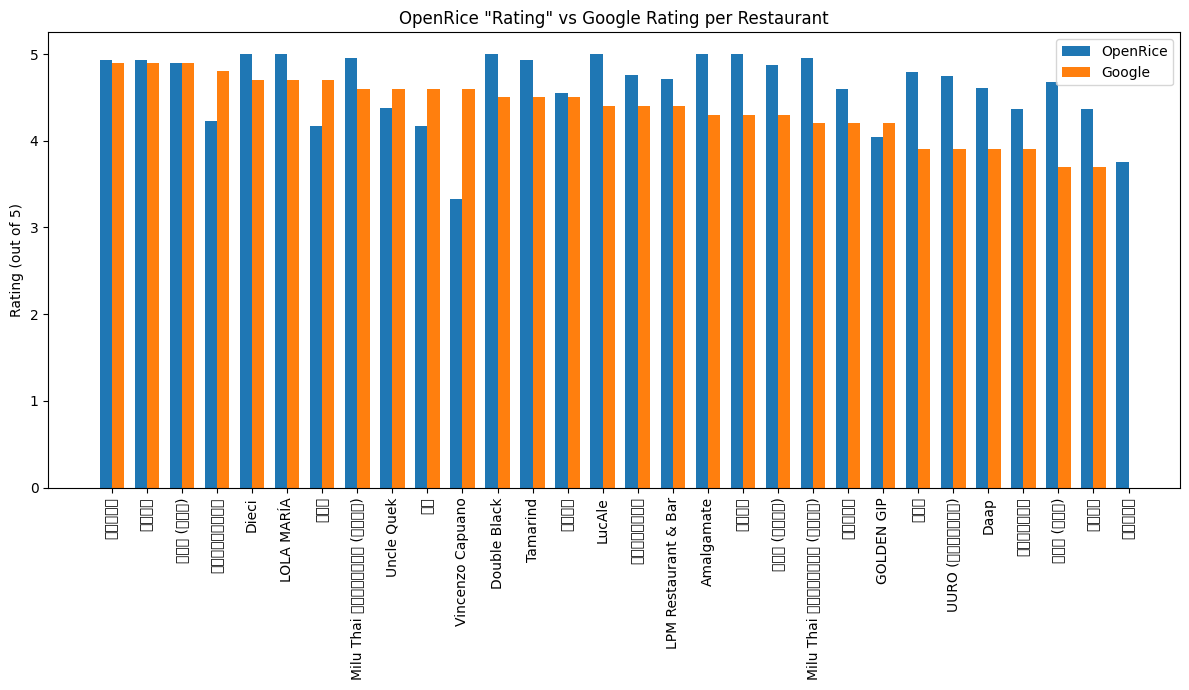

In [39]:
# Plot side-by-side bars of OpenRice rating vs Google rating

# For OpenRice, we don't have a single "rating", but can proxy with smile/(smile+cry)*5
def openrice_rating(row):
    smiles = row['openrice_smile']
    cry = row['openrice_cry']
    try:
        smiles = float(smiles)
        cry = float(cry)
        if smiles + cry > 0:
            return smiles / (smiles + cry) * 5
        else:
            return np.nan
    except:
        return np.nan

# Add/recalculate openrice_rating if needed
df['openrice_rating'] = df.apply(openrice_rating, axis=1)

# For google_rating, use the 'google_rating' column directly (already pre-extracted)
df['google_rating'] = pd.to_numeric(df['google_rating'], errors='coerce')

# Only keep rows where at least one rating is present
mask = (~df['openrice_rating'].isna()) | (~df['google_rating'].isna())
df_plot = df.loc[mask, ['restaurant', 'openrice_rating', 'google_rating']].reset_index(drop=True)

# Sort by OpenRice rating, fallback to Google if that is missing
df_plot = df_plot.sort_values(by=['google_rating', 'openrice_rating'], ascending=False)

# Prepare data for bar plot
x = np.arange(len(df_plot['restaurant']))  # label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 7))

rects1 = ax.bar(x - width/2, df_plot['openrice_rating'], width, label='OpenRice')
rects2 = ax.bar(x + width/2, df_plot['google_rating'], width, label='Google')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Rating (out of 5)')
ax.set_title('OpenRice "Rating" vs Google Rating per Restaurant')
ax.set_xticks(x)
ax.set_xticklabels(df_plot['restaurant'], rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
df.columns

Index(['restaurant', 'source_html', 'openrice_rank', 'openrice_district',
       'openrice_cuisine_tags', 'openrice_smile', 'openrice_cry',
       'openrice_bookmarks', 'openrice_url', 'google_extracted', 'google_name',
       'google_rating', 'google_rating_out_of', 'google_review_count',
       'google_category', 'google_price_range_text', 'google_hours_status',
       'google_place_fid', 'google_not_found_reason', 'google_detected_source',
       'openrice_rating'],
      dtype='str')